**Il faut mainteannt trouver un moyen d'attribuer une agence pour chacune des lots. De manière assez évidente, même si c'est une approximation, on relie chaque lot à l'agence qui lui est la plus proche.**

Pour cela, on partitionne la France en zones d'activité par agence. Chacun des lots sera ainsi dans la zone de l'agence la plus proche. 

In [14]:
# Cellule 1 : importations, connexion

# Nettoyage complet
print("Nettoyage...")
%reset -f

%whos

import numpy.random as rd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import pandas as pd 
from sqlalchemy import create_engine
from sqlalchemy.engine import URL
from sqlalchemy import text
import sqlalchemy
import gc
import os
import requests
import pyodbc
from datetime import datetime
from pandas import NaT
import math
from scipy.stats import expon
import geopandas as gpd
from shapely.geometry import Point
import contextily as ctx
from geopy.geocoders import Nominatim
from geopy.exc import GeocoderTimedOut, GeocoderUnavailable
import time
from scipy.stats import gaussian_kde
from sklearn.neighbors import KernelDensity
from shapely.geometry import Point, Polygon
from shapely.ops import unary_union, polygonize
from scipy.spatial import Voronoi
from shapely.geometry import box
from shapely.ops import unary_union
from geopy.distance import geodesic
from geovoronoi import voronoi_regions_from_coords

# Connexion pyodbc à SQL Server

conn_str = (
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=172.16.11.33;"
    "DATABASE=LogiProDev;"
    "UID=quentin;"
    "PWD={Barbidur1;SQL}"
)

conn = pyodbc.connect(conn_str)
cursor = conn.cursor()

requete_lots_adresses = """
SELECT 
    tj.lot_id,
    l.lot_actif,
    a.adresse_id,
    a.adr_adresse,
    a.adr_adresse_cp,
    a.adr_adresse_ville,
    CAST(a.adr_plan_x AS FLOAT) AS adr_plan_x,
    CAST(a.adr_plan_y AS FLOAT) AS adr_plan_y,
    CAST(a.adr_geo_location AS VARCHAR(255)) AS adr_geo_location,
    a.code_insee_id
FROM dbo.tj_offre_lot tj
JOIN dbo.t_lot l ON tj.lot_id = l.lot_id
JOIN dbo.t_adresse a ON l.adresse_id = a.adresse_id
"""

requete_agence_transaction = """ 
SELECT agence_id FROM dbo.t_transaction
"""

agence_transaction = pd.read_sql_query(requete_agence_transaction, conn)

print(agence_transaction.columns)

lots_adresses = pd.read_sql_query(requete_lots_adresses, conn)

print(lots_adresses.columns)

conn.commit()
cursor.close()
conn.close()

Nettoyage...
Interactive namespace is empty.


C:\Users\quent\AppData\Local\Temp\ipykernel_10156\2658653452.py:76: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  agence_transaction = pd.read_sql_query(requete_agence_transaction, conn)


Index(['agence_id'], dtype='object')


C:\Users\quent\AppData\Local\Temp\ipykernel_10156\2658653452.py:80: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  lots_adresses = pd.read_sql_query(requete_lots_adresses, conn)


Index(['lot_id', 'lot_actif', 'adresse_id', 'adr_adresse', 'adr_adresse_cp',
       'adr_adresse_ville', 'adr_plan_x', 'adr_plan_y', 'adr_geo_location',
       'code_insee_id'],
      dtype='object')


In [15]:
# Cellule 2 : filtres France métropolitaine et distance minimale pour tests

# 1. Charger les agences depuis le fichier Excel
localisations_agences = pd.read_excel("localisations_agences.xlsx")
localisations_agences = localisations_agences[localisations_agences["latitude"].notna()]

# 2. Filtrage géographique large (boîte englobante pour éviter les DROM-COM)
localisations_agences = localisations_agences[
    (localisations_agences['longitude'] >= -5) &
    (localisations_agences['longitude'] <= 10) &
    (localisations_agences['latitude'] >= 41) &
    (localisations_agences['latitude'] <= 51)
].reset_index(drop=True)

# 3. Conversion en GeoDataFrame en EPSG:4326
gdf_agences = gpd.GeoDataFrame(
    localisations_agences,
    geometry=gpd.points_from_xy(localisations_agences.longitude, localisations_agences.latitude),
    crs="EPSG:4326"
)

# 4. Télécharger et charger la France métropolitaine
geojson_url = "https://france-geojson.gregoiredavid.fr/repo/regions.geojson"
geojson_path = "regions-france.geojson"

if os.path.exists(geojson_path):
    os.remove(geojson_path)
    print(f"Fichier existant '{geojson_path}' supprimé.")

print("Téléchargement du GeoJSON de la France...")
response = requests.get(geojson_url)
if response.status_code == 200:
    with open(geojson_path, "wb") as f:
        f.write(response.content)
    print(f"Téléchargement terminé, taille fichier : {os.path.getsize(geojson_path)} octets.")
else:
    raise RuntimeError(f"Erreur téléchargement : statut HTTP {response.status_code}")

france = gpd.read_file(geojson_path)

codes_metropole = [
    "11", "24", "27", "28", "32", "44", "52", "53", "75", "76", "84", "93", "94"
]

france_metropole = france[france['code'].isin(codes_metropole)].copy()

# 5. Vérifier si france_metropole est bien défini (depuis Cellule 3), sinon erreur claire
if 'france_metropole' not in globals():
    raise RuntimeError("Erreur : 'france_metropole' n'est pas défini. Exécute la Cellule 3 d'abord.")

# 6. Reprojeter la France en EPSG:4326 (même CRS que gdf_agences) pour le test spatial
france_metropole_4326 = france_metropole.to_crs("EPSG:4326")

# 7. Union des géométries régionales en une seule pour représenter la métropole
france_metropole_geom = france_metropole_4326.unary_union

# 8. Filtrer les agences situées DANS la France métropolitaine
gdf_agences_metropole = gdf_agences[gdf_agences.geometry.within(france_metropole_geom)].copy()
print(f"Nombre d'agences en métropole avant filtrage distance : {len(gdf_agences_metropole)}")

# 9. Filtrage par distance minimale entre agences (en km)
min_distance_km = 0.023  # Ajustable
selected_points = []

def is_far_enough(candidate_point, selected_points, min_distance_km):
    for pt in selected_points:
        if geodesic((candidate_point.y, candidate_point.x), (pt.y, pt.x)).km < min_distance_km:
            return False
    return True

for idx, row in gdf_agences_metropole.iterrows():
    point = row.geometry
    if is_far_enough(point, selected_points, min_distance_km):
        selected_points.append(point)

# 10. Construction du GeoDataFrame filtré
gdf_filtrée = gdf_agences_metropole[gdf_agences_metropole.geometry.isin(selected_points)].reset_index(drop=True)

print(f"{len(gdf_filtrée)} agences sélectionnées, espacées d'au moins {min_distance_km} km, en métropole.")


Fichier existant 'regions-france.geojson' supprimé.
Téléchargement du GeoJSON de la France...
Téléchargement terminé, taille fichier : 489330 octets.
Nombre d'agences en métropole avant filtrage distance : 195


C:\Users\quent\AppData\Local\Temp\ipykernel_10156\65750222.py:55: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  france_metropole_geom = france_metropole_4326.unary_union


195 agences sélectionnées, espacées d'au moins 0.023 km, en métropole.


In [16]:
# Supposons que localisations_agences est ton DataFrame initial

# Supprimer les doublons basés sur latitude et longitude
localisations_agences = localisations_agences.drop_duplicates(subset=['latitude', 'longitude']).reset_index(drop=True)


Nombre d'agences utilisées pour Voronoi : 195


C:\Users\quent\AppData\Local\Temp\ipykernel_10156\2769941705.py:17: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  region_polys, region_pts = voronoi_regions_from_coords(coords, france_metropole.unary_union)


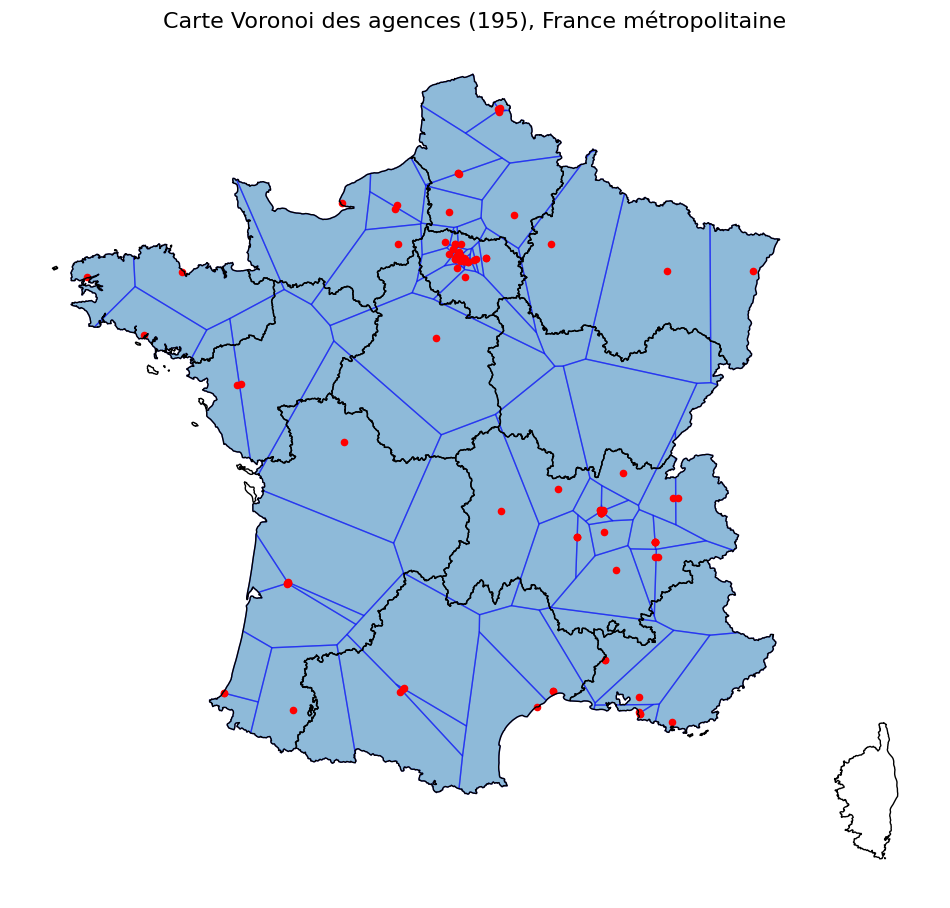

In [17]:
# Cellule 3 corrigée : affichage Voronoi à partir des agences déjà filtrées

# Assure-toi que france_metropole existe et est projeté en EPSG:2154
france_metropole = france_metropole.to_crs(epsg=2154)

# Utiliser les agences déjà filtrées (195 points, depuis Cellule 2)
gdf_proj = gdf_filtrée.to_crs(epsg=2154)

# Vérification utile (pour s'assurer qu'on part bien de 195 agences)
print(f"Nombre d'agences utilisées pour Voronoi : {len(gdf_proj)}")

# --- 3. Calculer Voronoi limité à la France métropolitaine

coords = np.array([(pt.x, pt.y) for pt in gdf_proj.geometry])

from geovoronoi import voronoi_regions_from_coords
region_polys, region_pts = voronoi_regions_from_coords(coords, france_metropole.unary_union)

gdf_voronoi = gpd.GeoDataFrame({'geometry': list(region_polys.values())}, crs=gdf_proj.crs)

# --- 4. Affichage

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 12))
france_metropole.boundary.plot(ax=ax, edgecolor='black', linewidth=1)
gdf_voronoi.plot(ax=ax, alpha=0.5, edgecolor='blue')
gdf_proj.plot(ax=ax, color='red', markersize=20)  # tu peux ajuster ici la taille des points
plt.title("Carte Voronoi des agences (195), France métropolitaine", fontsize=16)
plt.axis('off')
plt.show()


In [18]:
total_polygons = 0
for geom in gdf_voronoi.geometry:
    if geom.type == 'Polygon':
        total_polygons += 1
    elif geom.type == 'MultiPolygon':
        total_polygons += len(geom.geoms)

print(f"Nombre total de polygones élémentaires (en éclatant les MultiPolygons) : {total_polygons}")

Nombre total de polygones élémentaires (en éclatant les MultiPolygons) : 117


C:\Users\quent\AppData\Local\Temp\ipykernel_10156\1889340944.py:3: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  if geom.type == 'Polygon':
C:\Users\quent\AppData\Local\Temp\ipykernel_10156\1889340944.py:5: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  elif geom.type == 'MultiPolygon':


**A présent, on attribue à chaque lot une agence à partir des géométries des polygones des agences**

In [19]:
# 1. Créer une GeoDataFrame des agences
gdf_agences = gpd.GeoDataFrame(
    localisations_agences,
    geometry=gpd.points_from_xy(localisations_agences.longitude, localisations_agences.latitude),
    crs="EPSG:4326"
)

# 2. Reprojeter les deux en EPSG:2154
gdf_agences = gdf_agences.to_crs(epsg=2154)
gdf_voronoi = gdf_voronoi.to_crs(epsg=2154)

# 3. Copier la géométrie des polygones dans une colonne distincte avant le sjoin
gdf_voronoi = gdf_voronoi.copy()
gdf_voronoi['polygone'] = gdf_voronoi.geometry

# 4. Faire un spatial join pour associer chaque point à un polygone
# joined = gpd.sjoin(gdf_agences, gdf_voronoi[['polygone', 'geometry']], how='left', predicate='within')
joined = gpd.sjoin(gdf_agences, gdf_voronoi, how='left', predicate='within')

# 5. Ajouter la colonne 'polygone' au DataFrame d'origine
localisations_agences['polygone'] = joined['polygone'].values

print(localisations_agences.columns)

Index(['agence_id', 'agence_nom', 'agence_ville', 'agence_adresse',
       'agence_code_postal', 'adresse_complete', 'latitude', 'longitude',
       'polygone'],
      dtype='object')


In [20]:
# Créer une GeoDataFrame des agences avec leur polygone comme géométrie
gdf_agences_polygones = gpd.GeoDataFrame(
    localisations_agences.copy(),
    geometry=localisations_agences['polygone'],
    crs="EPSG:2154"
)

# def trouver_agence_pour_point(x, y, gdf_polygones):
#     point = Point(x, y)
#     match = gdf_polygones[gdf_polygones.geometry.contains(point)]
#     if not match.empty:
#         return match.iloc[0]  # Ou match.iloc[0]['nom_agence'] si tu veux le nom
#     else:
#         return None

# # Exemple avec un nouveau point (en Lambert 93)
# x_nouveau = 600000  # en mètres
# y_nouveau = 6700000

# resultat = trouver_agence_pour_point(x_nouveau, y_nouveau, gdf_agences_polygones)

# if resultat is not None:
#     print("Le point appartient à l'agence :")
#     print(resultat)
# else:
#     print("Le point n'appartient à aucun polygone.")

In [21]:
# 1. Copier et définir le polygone comme géométrie principale
gdf_agences_polygones = gpd.GeoDataFrame(
    localisations_agences.copy(),
    geometry=localisations_agences['polygone'],
    crs="EPSG:2154"
)

# 1. Garder uniquement les colonnes utiles
gdf_agences_polygones = gdf_agences_polygones[['agence_id', 'agence_nom', 'polygone']].copy()

# 2. Convertir en GeoDataFrame avec 'polygone' comme géométrie principale
gdf_agences_polygones = gpd.GeoDataFrame(gdf_agences_polygones, geometry='polygone', crs="EPSG:2154")

In [22]:
count_df = agence_transaction.groupby("agence_id").size().reset_index(name="nb_transactions")

agence_transaction = (
    agence_transaction
    .drop_duplicates(subset=["agence_id"])
    .merge(count_df, on="agence_id", how="left")
)

agence_transaction.head()

,agence_id,nb_transactions
0,8.0,26.0
1,10.0,13.0
2,18.0,7310.0
3,24.0,1018.0
4,25.0,2923.0


In [23]:
gdf_agences_polygones = gdf_agences_polygones.merge(
    agence_transaction[['agence_id', 'nb_transactions']],
    on='agence_id',
    how='left'  # on garde toutes les agences, même celles sans transaction
)

gdf_agences_polygones['nb_transactions'] = gdf_agences_polygones['nb_transactions'].fillna(0).astype(int)

gdf_agences_polygones.head()

gdf_agences_polygones.to_file("gdf_agences_polygones.geojson", driver="GeoJSON")